<a href="https://colab.research.google.com/github/JMS2510/sprint07_proyecto_ventas_multicanal_latam/blob/main/Copia_de_Sprint07_Webinar11_students_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 7 · Sesión práctica · Proyecto guiado con Python — Versión estudiante

**Duración:** 120 minutos  
**Pausa:** 5 minutos a la mitad  
**Modalidad:** Proyecto práctico guiado en Google Colab  
**Nivel:** Introductorio-intermedio  

En esta sesión vamos a trabajar como analistas de datos de una tienda multicanal LATAM. El objetivo no es memorizar código, sino aprender un flujo de trabajo práctico: cargar datos, explorarlos, limpiarlos, automatizar tareas simples, graficar, detectar outliers, segmentar ventas y cerrar con conclusiones accionables.

## Objetivos de aprendizaje

Al finalizar la sesión, la persona estudiante podrá:

1. Cargar un archivo `.csv` en Google Colab usando Pandas.
2. Explorar estructura, tipos de datos, valores nulos y métricas descriptivas.
3. Aplicar reglas simples de limpieza sin modificar el dataset original directamente.
4. Usar listas, ciclos `for`, ciclos `while` y funciones pequeñas para automatizar revisiones.
5. Calcular KPIs de negocio con `groupby()`.
6. Crear gráficas sencillas con `.plot()`.
7. Crear gráficas agrupadas con Seaborn usando `hue`.
8. Detectar posibles outliers con la regla IQR.
9. Crear segmentos de venta con funciones y `.apply()`.
10. Comunicar hallazgos con una estructura clara: contexto, hallazgo, evidencia e implicación.

## Agenda sugerida · 120 minutos

| Tiempo | Bloque | Actividad | Modalidad |
|---:|---|---|---|
| 0–10 min | Kickoff | Entender el caso de negocio y las preguntas guía | Discusión rápida |
| 10–20 min | Setup | Preparar Colab, cargar librerías y leer el CSV | Demo guiada |
| 20–35 min | Exploración inicial | `head()`, `shape`, `info()`, nulos y descriptivos | Coding together |
| 35–50 min | Limpieza | Copia segura, normalización de textos e imputaciones simples | Coding together |
| 50–60 min | Automatización | `for`, `while` y funciones pequeñas | Mini-reto guiado |
| 60–65 min | Pausa | Descanso corto | Break |
| 65–80 min | KPIs | Revenue, margen, ticket promedio, devoluciones | Coding together |
| 80–95 min | Visualización | Gráficas con `.plot()` y lectura de patrones | Demo + práctica |
| 95–108 min | Seaborn agrupado | Comparar categorías/canales/tipos de cliente con `hue` | Práctica guiada |
| 108–116 min | Outliers y segmentación | IQR y clasificación de ventas | Reto final |
| 116–120 min | Cierre | Validación, takeaways y canales de ayuda | Plenaria |

## Caso de negocio · Ventas Multicanal LATAM

La empresa vende productos por **Web**, **App**, **Tienda física** y **WhatsApp** en varios países de Latinoamérica. El equipo directivo quiere responder:

- ¿Qué países, canales y categorías generan más ingreso?
- ¿Dónde se concentra el margen?
- ¿Qué segmentos de ventas existen?
- ¿Hay ventas atípicas que puedan distorsionar el análisis?
- ¿Qué visualizaciones ayudan a explicar los hallazgos?

Durante la sesión se irá construyendo una versión limpia del dataset y un pequeño set de hallazgos para presentar al negocio.

## Diccionario de datos

| Columna | Descripción |
|---|---|
| `venta_id` | Identificador único de la venta |
| `fecha` | Fecha de la venta |
| `pais`, `region`, `ciudad` | Ubicación de la operación |
| `canal` | Canal de venta: Web, App, Tienda física o WhatsApp |
| `categoria` | Categoría del producto vendido |
| `metodo_pago` | Medio de pago usado por el cliente |
| `tipo_cliente` | Cliente nuevo o recurrente |
| `unidades` | Cantidad de unidades vendidas |
| `precio_unitario` | Precio unitario antes de descuentos |
| `descuento_pct` | Porcentaje de descuento aplicado |
| `ingreso` | Valor de la venta después del descuento |
| `costo` | Costo estimado de la venta |
| `margen` | Diferencia entre ingreso y costo |
| `edad_cliente` | Edad del cliente |
| `satisfaccion` | Calificación de satisfacción de 1 a 10 |
| `dias_entrega` | Días transcurridos hasta la entrega |
| `devolucion` | Indica si la venta fue devuelta |

## Ejercicio 0 · Kickoff del proyecto \(10 min\)

Antes de ejecutar código, responde en parejas:

1. ¿Cuál sería la métrica principal para medir tamaño de negocio?
- Ingreso
2. ¿Cuál sería la métrica principal para medir rentabilidad?
- Margen
3. ¿Qué columnas podrían tener valores nulos?
- Devolucion, Canal, edad
4. ¿Qué columnas usarías para crear gráficos comparativos?
-Categoria, margen por pais ingros por canal ingresos por fecha
5. ¿Qué parte del proceso parece repetitiva y podría automatizarse?
- Limpieza de datos, resumen ejecutivo

> **Criterio:** No buscamos una única respuesta correcta. Buscamos justificar qué columna usaríamos y por qué.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


## Preparación del entorno en Google Colab

Google Colab ejecuta Python en la nube. Cada bloque de código se llama **celda**. Para ejecutar una celda puedes usar `Shift + Enter`.

En esta sesión usaremos:

- `pandas` para trabajar con tablas.
- `matplotlib` para gráficas básicas.
- `seaborn` para gráficas agrupadas más legibles.

> Si Colab se desconecta, normalmente basta con volver a ejecutar las celdas desde el inicio.

In [1]:
# ============================================================
# 1. Importar librerías
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual básica
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## Cargar el dataset

Sube el archivo `sprint07_proyecto_ventas_multicanal_latam.csv` a Colab y ejecútalo desde la misma carpeta del notebook.

También podrías cargarlo desde una URL pública de GitHub si luego decides subirlo a un repositorio.

In [2]:
# ============================================================
# 2. Cargar archivo CSV
# ============================================================

archivo = 'https://raw.githubusercontent.com/ljpiere/tpdata_python/refs/heads/main/DA/DA_students/datasets/sprint07_proyecto_ventas_multicanal_latam.csv'

df = pd.read_csv(archivo)

print('Dataset cargado')
print('Filas y columnas:', df.shape)
df.head()


Dataset cargado
Filas y columnas: (180, 19)


,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No


## Ejercicio 1 · Primer vistazo al dataset \(15 min\)

Tareas:

1. Mostrar las primeras filas.
2. Revisar cantidad de filas y columnas.
3. Listar nombres de columnas.
4. Revisar tipos de datos.
5. Identificar columnas numéricas y categóricas.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [3]:
# Mostrar las primeras filas.
print(df.head())

  venta_id       fecha      pais    region        ciudad          canal  \
0    V0081  2026-01-26  Colombia    Andina  Barranquilla            Web   
1    V0143  2026-03-11     Chile  Cono Sur    Valparaíso            Web   
2    V0077  2026-04-01  Colombia    Andina          Cali  Tienda física   
3    V0156  2026-01-19  Colombia    Andina      Medellín            Web   
4    V0087  2026-02-18      Perú    Andina      Arequipa            Web   

  categoria      metodo_pago tipo_cliente  unidades  precio_unitario  \
0      Moda   Tarjeta débito   Recurrente         1       459,000.00   
1  Deportes         Efectivo        Nuevo         3       776,000.00   
2     Hogar  Tarjeta crédito        Nuevo         2       190,000.00   
3   Belleza   Tarjeta débito        Nuevo         2        70,000.00   
4      Moda  Tarjeta crédito        Nuevo         1        82,000.00   

   descuento_pct      ingreso        costo     margen  edad_cliente  \
0           0.25   344,250.00   265,729.41  7

In [4]:
# Revisar cantidad de filas y columnas.
print('Filas y Columnas:', df.shape)

Filas y Columnas: (180, 19)


In [5]:
# Listar nombres de columnas.
print('Columnas:', df.columns )

Columnas: Index(['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria',
       'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario',
       'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente',
       'satisfaccion', 'dias_entrega', 'devolucion'],
      dtype='object')


In [6]:
# Identificar columnas numéricas y categóricas.
# Columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
# Columnas categóricas (objetos tipo texto)
columnas_categoricas = df.select_dtypes(include=['object']).columns

print('Columnas númericas:', columnas_numericas)
print('Columnas categóricas:', columnas_categoricas)

Columnas númericas: Index(['unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo',
       'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega'],
      dtype='object')
Columnas categóricas: Index(['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria',
       'metodo_pago', 'tipo_cliente', 'devolucion'],
      dtype='object')


## Ejercicio 2 · Revisión de valores nulos \(10 min\)

Tareas:

1. Contar nulos por columna.
2. Calcular el porcentaje de nulos.
3. Decidir qué columnas requieren limpieza.

> Para una primera práctica, usaremos reglas simples. En proyectos reales, la decisión debe validarse con negocio o con la fuente de datos.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [10]:
# Contar nulos por columna y porcentaje
#nulos_por_columna = df.isnull().sum()
#print("Nulos por columna:\n", nulos_por_columna)

#porcentaje_nulos = (df.isnull().mean() * 100).round(2)
#print("Porcentaje de nulos:\n", porcentaje_nulos)

#df.isna().sum().sort_values(ascending=False)/len(df)

nulos = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct'  : df.isna().mean()*100
}).sort_values('nulos', ascending=False)
nulos



,nulos,pct
metodo_pago,11,6.11
satisfaccion,9,5.00
dias_entrega,7,3.89
edad_cliente,5,2.78
pais,0,0.00
venta_id,0,0.00
fecha,0,0.00
categoria,0,0.00
region,0,0.00
canal,0,0.00


Se puede observar que las columnas que requieren de limpieza son:

- metodo_pago
- satisfaccion
- dias_entrega
- edad_cliente

## Ejercicio 3 · Crear una copia limpia \(15 min\)

Regla de trabajo: no modificamos el dataset original directamente. Creamos `df_limpio` para preservar la trazabilidad.

Aplicaremos cuatro decisiones:

1. Convertir `fecha` a tipo fecha.
2. Normalizar textos en `canal`.
3. Completar `metodo_pago` con `No informado`.
4. Completar variables numéricas con la mediana.

In [8]:
# Crear una copia limpia
df_limpio = df.copy()

In [9]:
# Converti fecha
df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'], errors='coerce')
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   venta_id         180 non-null    object        
 1   fecha            180 non-null    datetime64[ns]
 2   pais             180 non-null    object        
 3   region           180 non-null    object        
 4   ciudad           180 non-null    object        
 5   canal            180 non-null    object        
 6   categoria        180 non-null    object        
 7   metodo_pago      169 non-null    object        
 8   tipo_cliente     180 non-null    object        
 9   unidades         180 non-null    int64         
 10  precio_unitario  180 non-null    float64       
 11  descuento_pct    180 non-null    float64       
 12  ingreso          180 non-null    float64       
 13  costo            180 non-null    float64       
 14  margen           180 non-null    float64  

In [14]:
# Normalizar textos en canal.
df_limpio['canal'] = df_limpio['canal'].str.title()
#df_limpio['canal'].unique()

In [15]:
# Completar metodo_pago con No informado.
df_limpio['metodo_pago'] = df_limpio['metodo_pago'].fillna('No informado')
df_limpio['metodo_pago'].unique()

array(['Tarjeta débito', 'Efectivo', 'Tarjeta crédito', 'Wallet',
       'Transferencia', 'No informado'], dtype=object)

In [16]:
# Completar variables numéricas con la mediana.
#columnas_numericas = df_limpio.select_dtypes(include=['int64','float64']).columns
lista_numericos = ["satisfaccion", "dias_entrega", "edad_cliente"]

for numero in lista_numericos:
    df_limpio[numero] = df_limpio[numero].fillna(df_limpio[numero].median())
df_limpio.isna().sum()

,0
venta_id,0
fecha,0
pais,0
region,0
ciudad,0
canal,0
categoria,0
metodo_pago,0
tipo_cliente,0
unidades,0


## Ejercicio 4 · Automatización con `for`, `while` y funciones \(10 min\)

En análisis de datos hay tareas repetitivas: revisar varias columnas, calcular varios resúmenes o generar varios gráficos. Para eso usamos automatización básica.

Primero recorreremos columnas numéricas con `for`.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [40]:
# Automatización con Funcion
# columnas_numericas = df_limpio.select_dtypes(include=['int64','float64']).columns
# for col in columnas_numericas:
#     maximo = df_limpio[col].max()
#     minimo = df_limpio[col].min()
#     print(f"Columna: {col} | Mínimo: {minimo} | Máximo: {maximo}")
def resumen(tabla, columna):
  estadisticas = {
      'Columna':columna,
      'min':   tabla[columna].min(),
      'media': tabla[columna].mean(),
      'max':   tabla[columna].max()
  }
  return estadisticas
# def col_numericas(columnas_numericas):
#   for x in columnas_numericas:
#    media = df_limpio[x].mean()
#    maximo = df_limpio[x].max()
#    minimo = df_limpio[x].min()
#    print(f"Columna: {x}")
#    print(f"Media: {media}")
#    print(f"Maximo: {maximo}")
#    print(f"Mínimo: {minimo}")
#    print()
#    col_numericas(columnas_numericas)

In [41]:
for col in columnas_numericas:
  print(resumen(df_limpio, col))

{'Columna': 'unidades', 'min': 1, 'media': np.float64(1.8388888888888888), 'max': 15}
{'Columna': 'precio_unitario', 'min': 49000.0, 'media': np.float64(805183.3333333334), 'max': 2942000.0}
{'Columna': 'descuento_pct', 'min': 0.0, 'media': np.float64(0.09194444444444443), 'max': 0.25}
{'Columna': 'ingreso', 'min': 45600.0, 'media': np.float64(1309338.7777777778), 'max': 9770400.0}
{'Columna': 'costo', 'min': 23964.17, 'media': np.float64(852555.4916111112), 'max': 6621546.86}
{'Columna': 'margen', 'min': 14264.88, 'media': np.float64(456783.2861666666), 'max': 4376769.0}
{'Columna': 'edad_cliente', 'min': 18.0, 'media': np.float64(35.01111111111111), 'max': 62.0}
{'Columna': 'satisfaccion', 'min': 2.0, 'media': np.float64(7.433333333333334), 'max': 10.0}
{'Columna': 'dias_entrega', 'min': 1.0, 'media': np.float64(4.122222222222222), 'max': 24.0}


# Pausa · 5 minutos

Antes de seguir, verifica que tienes creadas estas variables:

- `df`
- `df_limpio`
- `columnas_revision`
- `resumen_numerico`

Después de la pausa, pasamos de preparación de datos a análisis de negocio y visualización.

## Ejercicio 5 · KPIs del proyecto \(15 min\)

Vamos a calcular métricas que el negocio podría usar:

- Ingreso total.
- Margen total.
- Margen porcentual.
- Ticket promedio.
- Tasa de devolución.
- Satisfacción promedio.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [43]:
Ingreso_total = df_limpio['ingreso'].sum()
Margen_total = df_limpio['margen'].sum()
Margen_porcentual = Margen_total / Ingreso_total
Ticket_promedio = df_limpio['ingreso'].mean()
Tasa_devolución = (df_limpio['devolucion'] == 'Si').mean()
Satisfacción_promedio = df_limpio['satisfaccion'].mean()

print(f"Ingreso total: {Ingreso_total}")
print(f"Margen total: {Margen_total}")
print(f"Margen porcentual: {Margen_porcentual}")
print(f"Ticket promedio: {Ticket_promedio}")
print(f"Tasa de devolución: {Tasa_devolución}")
print(f"Satisfacción promedio: {Satisfacción_promedio}")

Ingreso total: 235680980.0
Margen total: 82220991.50999999
Margen porcentual: 0.3488656212732991
Ticket promedio: 1309338.7777777778
Tasa de devolución: 0.0
Satisfacción promedio: 7.433333333333334


## Ejercicio 6 · Gráficas sencillas con `.plot()` \(15 min\)

`.plot()` es una forma simple de crear visualizaciones directamente desde Pandas. Es ideal para empezar porque se conecta fácil con `groupby()`.

Crearemos:

1. Barras de ingreso por país.
2. Barras horizontales de ingreso por categoría.
3. Línea de ingreso por mes.
4. Histograma de ingresos.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


,ingreso
pais,
Chile,"66,865,850.00"
Colombia,"61,845,580.00"
México,"56,305,900.00"
Perú,"50,663,650.00"


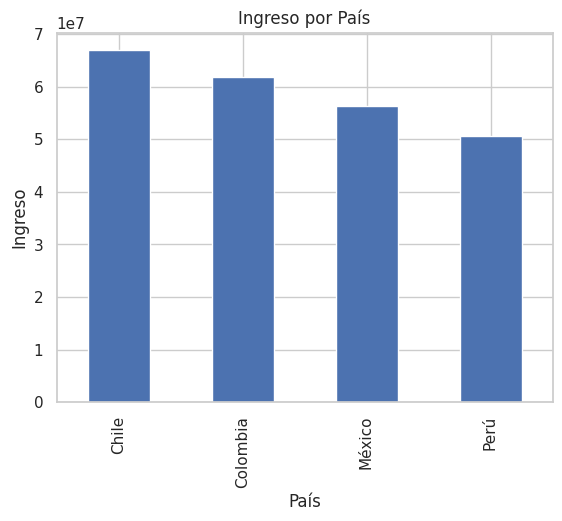

In [46]:
# Barras de ingreso por pais
ingreso_pais = df_limpio.groupby('pais')['ingreso'].sum().sort_values(ascending=False)
display(ingreso_pais)
# Grafico
ingreso_pais.plot(kind='bar')
plt.title('Ingreso por País')
plt.xlabel('País')
plt.ylabel('Ingreso')
plt.show()

,ingreso
categoria,
Belleza,"9,412,300.00"
Moda,"10,789,050.00"
Deportes,"33,122,030.00"
Hogar,"41,618,350.00"
Tecnología,"140,739,250.00"


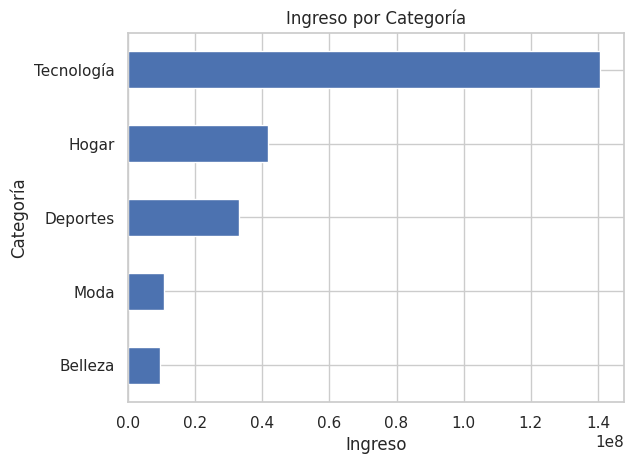

In [51]:
# Barras horizontales de ingreso por categoría
ingreso_categoria = df_limpio.groupby('categoria')['ingreso'].sum().sort_values(ascending=True)
display(ingreso_categoria)
# Grafico
ingreso_categoria.plot(kind='barh')
plt.title('Ingreso por Categoría')
figzize=(8,4
)
plt.xlabel('Ingreso')
plt.ylabel('Categoría')
plt.show()

,ingreso
mes,
1,"58,585,400.00"
2,"52,525,730.00"
3,"76,039,150.00"
4,"48,530,700.00"


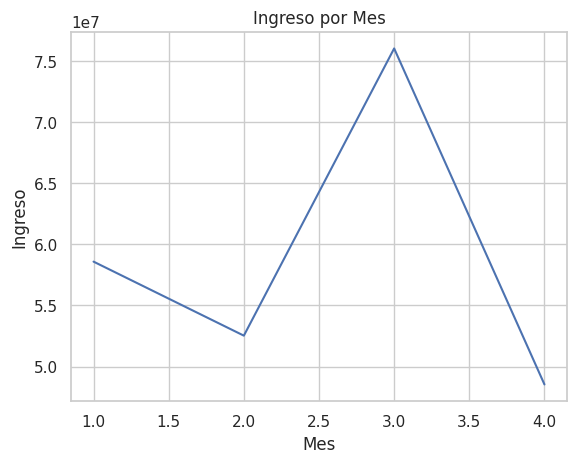

In [55]:
# Línea de ingreso por mes.
df_limpio['mes'] = df_limpio['fecha'].dt.month
ingreso_mes = df_limpio.groupby('mes')['ingreso'].sum()
display(ingreso_mes)
# Grafico
ingreso_mes.plot(kind='line')
marker='o'
plt.title('Ingreso por Mes')
figsize=(8,4
)
plt.xlabel('Mes')
plt.ylabel('Ingreso')
plt.show()

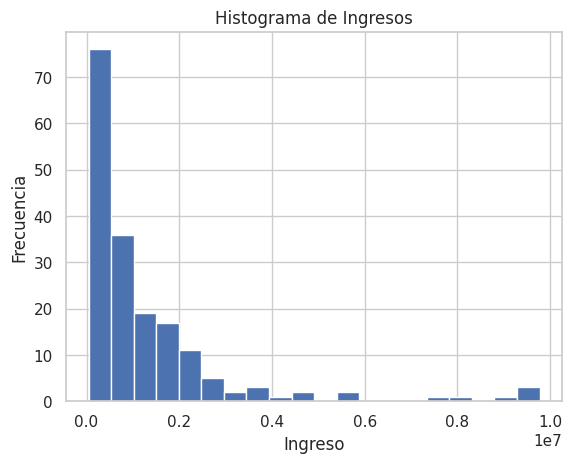

In [57]:
# Histograma de Ingresos
df_limpio['ingreso'].plot(kind='hist', bins=20)
plt.title('Histograma de Ingresos')
figsize=(8,4
)
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()
#

## Ejercicio 7 · Gráficas agrupadas con Seaborn \(13 min\)

Seaborn permite comparar grupos de forma más clara usando argumentos como `hue`.

Crearemos:

1. Ingreso total por categoría separado por canal.
2. Margen porcentual por canal separado por tipo de cliente.
3. Distribución de ingresos por canal y tipo de cliente.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


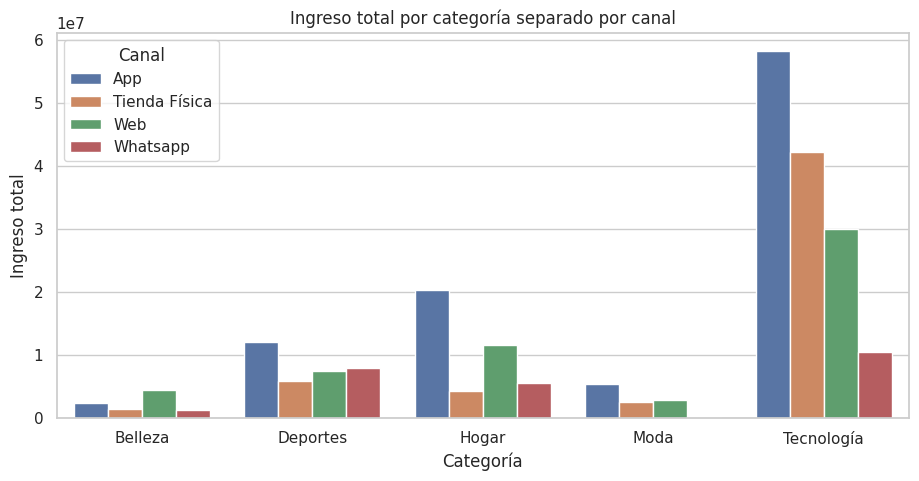

In [103]:
# Ingreso total por categoría separado por canal
resume_categoria = (df_limpio.groupby(['categoria', 'canal'],as_index=False)
.agg(Ingreso_total=('ingreso', 'sum')))
# Grafico
plt.figure(figsize=(11,5))
sns.barplot(data=resume_categoria, x='categoria', y='Ingreso_total', hue='canal')
plt.title('Ingreso total por categoría separado por canal')
plt.xlabel('Categoría')
plt.ylabel('Ingreso total')
plt.legend(title='Canal')
plt.show();

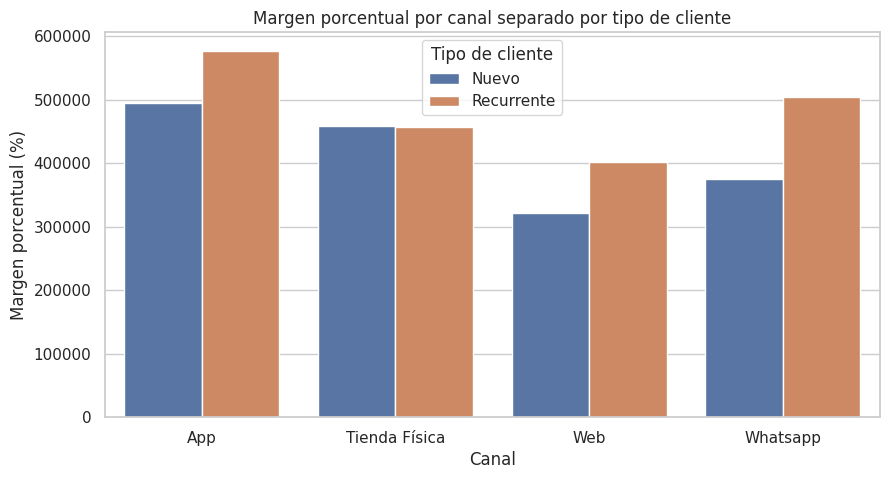

In [101]:
# Margen porcentual por canal separado por tipo de cliente.
#df_limpio.info()
# Margen porcentual por canal y tipo de cliente
resume_margen = (df_limpio.groupby(['canal', 'tipo_cliente'], as_index=False)
                 .agg(Margen=('margen', 'mean')))

# Gráfico
plt.figure(figsize=(10,5))
sns.barplot(data=resume_margen, x='canal', y='Margen', hue='tipo_cliente')
plt.title('Margen porcentual por canal separado por tipo de cliente')
plt.xlabel('Canal')
plt.ylabel('Margen porcentual (%)')
plt.legend(title='Tipo de cliente')
plt.show()


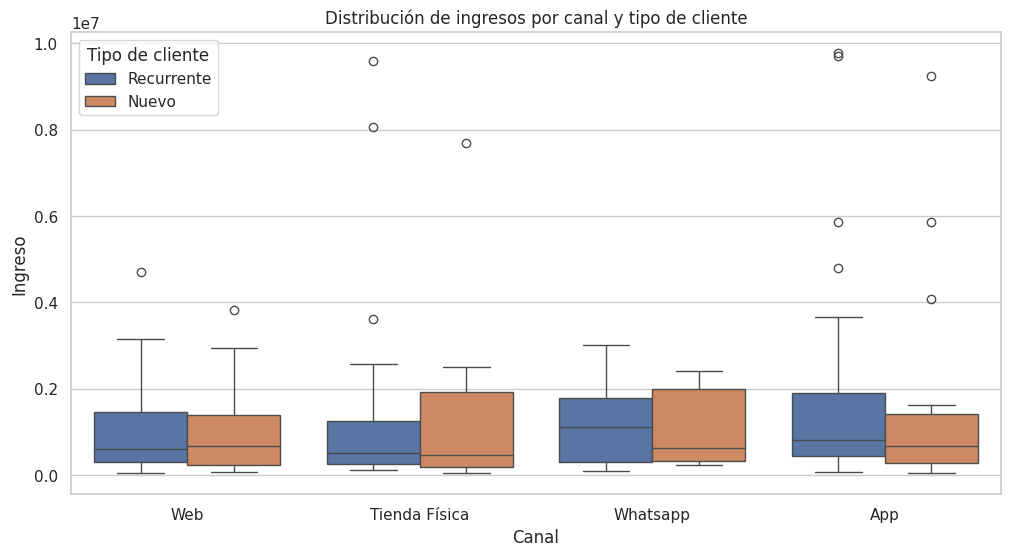

In [102]:
# Distribución de ingresos por canal y tipo de cliente.
# Distribución de ingresos por canal y tipo de cliente
plt.figure(figsize=(12,6))
sns.boxplot(data=df_limpio, x='canal', y='ingreso', hue='tipo_cliente')
plt.title('Distribución de ingresos por canal y tipo de cliente')
plt.xlabel('Canal')
plt.ylabel('Ingreso')
plt.legend(title='Tipo de cliente')
plt.show()


## Ejercicio 8 · Outliers con IQR \(8 min\)

La regla IQR permite detectar valores inusualmente altos o bajos.

No significa que esos valores estén mal. Significa que deben revisarse antes de sacar conclusiones.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [84]:
# TODO estudiante: escribe aquí tu código.
# Función para calcular límites IQR
def calcular_limites_iqr(tabla,columna):
    Q1 = tabla[columna].quantile(0.25)
    Q3 = tabla[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

In [85]:
down, upper = calcular_limites_iqr(df_limpio, 'ingreso')

print('limite Inferiror:', down)
print('limite Superior:',  upper)

limite Inferiror: -1670000.0
limite Superior: 3554200.0


In [90]:
from numpy import outer
# Indentificar Ventas Atípicas por Ingreso
outliers = df_limpio[(df_limpio['ingreso'] < down) |
                      (df_limpio['ingreso'] > upper)]
print('Cantindad de posibles outliers:', len(outliers))
display(outliers)

Cantindad de posibles outliers: 14


,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion,mes
8,V0068,2026-01-15,Perú,Andina,Lima,App,Tecnología,Tarjeta débito,Recurrente,2,"2,668,000.00",0.10,"4,802,400.00","3,361,641.13","1,440,758.87",31.00,7.00,5.00,No,1
12,V0037,2026-04-18,Chile,Cono Sur,Santiago,App,Tecnología,No informado,Nuevo,10,"2,865,000.00",0.15,"9,253,950.00","6,477,765.00","2,776,185.00",18.00,7.00,3.00,No,4
18,V0047,2026-04-10,Chile,Cono Sur,Concepción,App,Hogar,Efectivo,Nuevo,4,"1,021,000.00",0.00,"4,084,000.00","2,905,456.71","1,178,543.29",50.00,8.00,3.00,No,4
32,V0138,2026-03-12,Chile,Cono Sur,Santiago,Tienda Física,Tecnología,Tarjeta débito,Recurrente,4,"2,123,000.00",0.05,"8,067,400.00","4,434,366.65","3,633,033.35",29.00,7.00,3.00,No,3
49,V0132,2026-01-18,Colombia,Andina,Cali,Web,Tecnología,Tarjeta débito,Recurrente,2,"2,619,000.00",0.10,"4,714,200.00","2,990,932.39","1,723,267.61",39.00,7.00,2.00,No,1
76,V0160,2026-02-22,Colombia,Andina,Cali,Web,Tecnología,Tarjeta débito,Nuevo,2,"2,244,000.00",0.15,"3,814,800.00","2,670,543.63","1,144,256.37",32.00,10.00,2.00,No,2
92,V0170,2026-02-23,Colombia,Andina,Bogotá,App,Deportes,Efectivo,Nuevo,15,"417,000.00",0.10,"5,854,680.00","3,395,714.40","2,458,965.60",34.00,10.00,3.00,No,2
99,V0104,2026-03-04,Perú,Andina,Trujillo,App,Tecnología,Transferencia,Recurrente,4,"2,714,000.00",0.10,"9,770,400.00","5,393,631.00","4,376,769.00",34.00,8.00,4.00,No,3
109,V0121,2026-03-06,Colombia,Andina,Bogotá,Tienda Física,Tecnología,Wallet,Recurrente,2,"2,263,000.00",0.20,"3,620,800.00","2,482,181.93","1,138,618.07",28.00,7.00,1.00,No,3
116,V0064,2026-01-26,México,Norte,Guadalajara,Tienda Física,Tecnología,Tarjeta crédito,Nuevo,3,"2,853,000.00",0.10,"7,703,100.00","5,208,330.77","2,494,769.23",25.00,6.00,5.00,No,1


## Ejercicio 9 · Segmentación de ventas \(8 min\)

Segmentar ayuda a convertir números en etiquetas interpretables. Vamos a clasificar cada venta por tamaño de ingreso.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [93]:
# Función para segmentación
def clasificar_venta(ingreso):
    if ingreso >= 4_000_000:
         return 'Alta'
    elif ingreso >= 1_500_000:
         return 'Media'
    else:
         return 'Baja'

In [97]:
# Conteo por Segmento
df_limpio['segmento_venta'] = df_limpio['ingreso'].apply(clasificar_venta)
#segmento_conteo = df_limpio['segmento'].value_counts()
df_limpio[['ingreso', 'segmento_venta']]
#

,ingreso,segmento_venta
0,"344,250.00",Baja
1,"2,328,000.00",Media
2,"323,000.00",Baja
3,"133,000.00",Baja
4,"77,900.00",Baja
...,...,...
175,"623,700.00",Baja
176,"1,609,600.00",Media
177,"918,000.00",Baja
178,"2,116,800.00",Media


## Ejercicio 10 · Reto final del proyecto \(8 min\)

Construye una tabla final con una recomendación de negocio.

Tarea:

1. Agrupa por `pais`, `canal` y `categoria`.
2. Calcula ingreso total, margen total, cantidad de ventas y margen porcentual.
3. Ordena de mayor a menor ingreso.
4. Selecciona los 10 primeros registros.
5. Escribe una conclusión usando esta estructura:

> En `[país/canal/categoría]` se observa `[hallazgo]`, porque `[evidencia]`. Esto sugiere `[acción o pregunta de negocio]`.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  
El objetivo es construir una tabla final que resuma los principales indicadores de negocio (ingreso total, margen total, número de ventas y margen porcentual) agrupados por país, canal y categoría. Después se ordena por ingreso y se seleccionan los 10 registros más relevantes para redactar una recomendación de negocio basada en evidencia.

**Mi procedimiento / fórmula / consulta:**  
Agrupé el DataFrame df_limpio por las columnas pais, canal y categoria.

Calculé:
Ingreso_total con la suma de la columna ingreso.
Margen_total con la suma de la columna margen.
Ventas con el conteo de la columna venta_id.
Margen porcentual como (margen_total / ingreso_total) * 100.
Ordené la tabla resultante de mayor a menor ingreso.
Seleccioné los 10 primeros registros para el análisis final.

**Resultado obtenido:**  
La tabla muestra que los mayores ingresos se concentran en Tecnología y en canales como App, Web y Tienda Física, destacando países como Perú, Chile, Colombia y México. Por ejemplo:
Perú / App / Tecnología → Ingreso total ≈ 26.9M, Margen total ≈ 10.1M, Ventas = 7.
Chile / Tienda Física / Tecnología → Ingreso total ≈ 22.7M, Margen total ≈ 8.1M, Ventas = 5.
Colombia / Web / Tecnología → Ingreso total ≈ 15.8M, Margen total ≈ 5.0M, Ventas = 6.

**Conclusión breve:**  
En Perú / canal App / categoría Tecnología se observa el mayor ingreso total (≈26.9M), porque además presenta un margen elevado (≈10.1M) y un número de ventas consistente (7). Esto sugiere priorizar estrategias de marketing y expansión en el canal App para la categoría Tecnología en Perú, ya que es el segmento más rentable.

In [105]:
# Tabla final para recomendación
# Agrupar por país, canal y categoría
tabla_final = (df_limpio.groupby(['pais', 'canal', 'categoria'], as_index=False)
               .agg(
                   Ingreso_total=('ingreso', 'sum'),
                   Margen_total=('margen', 'sum'),
                   Ventas=('venta_id', 'count'),   # o la columna que represente cada venta
                   Margen=('margen', lambda x: (x.sum()/df_limpio['ingreso'].sum())*100)
               ))

# Ordenar de mayor a menor ingreso
tabla_final = tabla_final.sort_values(by='Ingreso_total', ascending=False)

# Seleccionar los 10 primeros registros
top10 = tabla_final.head(10)

print(top10)


        pais          canal   categoria  Ingreso_total  Margen_total  Ventas  \
55      Perú            App  Tecnología  26,959,450.00 10,158,490.79       7   
7      Chile  Tienda Física  Tecnología  22,767,300.00  8,119,124.47       5   
4      Chile            App  Tecnología  20,588,850.00  6,497,859.86       6   
27  Colombia            Web  Tecnología  15,838,150.00  5,008,654.70       6   
16  Colombia            App       Hogar  10,544,700.00  3,443,056.33       9   
41    México  Tienda Física  Tecnología   9,590,400.00  3,185,700.50       3   
46    México            Web  Tecnología   8,444,000.00  3,463,633.51       5   
36    México            App  Tecnología   8,215,350.00  2,558,976.66       4   
22  Colombia  Tienda Física  Tecnología   6,253,200.00  1,856,716.73       3   
44    México            Web       Hogar   6,221,400.00  2,149,599.07       4   

    Margen  
55    4.31  
7     3.44  
4     2.76  
27    2.13  
16    1.46  
41    1.35  
46    1.47  
36    1.09  
22

## Preguntas de validación de conocimiento

Responde individualmente y luego valida en plenaria:

1. ¿Por qué creamos `df_limpio = df.copy()` antes de limpiar?
2. ¿Qué diferencia hay entre `df.head()` y `df.info()`?
3. ¿Para qué sirve `groupby()` en un análisis de negocio?
4. ¿Qué ventaja tiene usar un ciclo `for` al revisar varias columnas?
5. ¿Qué problema puede ocurrir si eliminamos outliers sin analizarlos?
6. ¿Qué aporta Seaborn frente a una gráfica básica con `.plot()`?
7. ¿Qué significa usar `hue` en una gráfica de Seaborn?
8. ¿Qué archivo exportamos al final y para qué serviría?

### Mis respuestas

> Escribe aquí tus respuestas antes de la discusión en clase.

1.Para no modificar el dataset original por seguridad

2.df.head() muestra las primeras filas del DataFrame (útil para ver ejemplos de datos).
df.info() da un resumen de la estructura: número de filas, columnas, tipos de datos y valores nulos.

3.Permite agrupar datos por categorías (ej. país, canal, producto) y calcular métricas agregadas como sumas, promedios o conteos. Es clave para responder preguntas de negocio como “¿qué canal genera más ingresos?” o “¿qué categoría tiene mayor margen?”.

4.Evita repetir código. Con un for podemos aplicar la misma operación (ej. revisar nulos, calcular distribuciones) a varias columnas de forma automática y más eficiente.

5.Podemos perder información valiosa. A veces los outliers representan casos reales importantes (ej. clientes premium, ventas excepcionales). Eliminarlos sin análisis puede distorsionar las conclusiones.

6.Seaborn ofrece gráficos más estéticos y con mayor capacidad de comparación entre grupos (ej. hue, col, row). Además, integra estadísticas y distribuciones de manera más sencilla.

7.Nos permite diferenciar los datos por una categoría adicional usando colores. Ejemplo: ingresos por canal separados por tipo de cliente.

8.Generalmente exportamos un archivo CSV o Excel con los resultados finales. Sirve para compartir hallazgos, documentar el análisis y usarlo en reportes o dashboards de negocio.
